<a href="https://colab.research.google.com/github/ysn-gachon/AI-Class-202335225-nayeonsu/blob/main/Week6/abalone_Regression_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np

import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/abalone.csv')
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['Sex'] = encoder.fit_transform(df['Sex'])

# 나중에 클래스 이름을 확인하고 싶을 때
# print(encoder.classes_)
df.head()

,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0,2,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,1,2,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,2,0,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,3,2,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,4,1,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 41.0570 - mse: 41.0570 - val_loss: 11.4521 - val_mse: 11.4521
Epoch 2/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 10.2638 - mse: 10.2638 - val_loss: 6.6304 - val_mse: 6.6304
Epoch 3/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.1502 - mse: 8.1502 - val_loss: 5.7614 - val_mse: 5.7614
Epoch 4/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.0883 - mse: 8.0883 - val_loss: 5.6175 - val_mse: 5.6175
Epoch 5/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7448 - mse: 6.7448 - val_loss: 5.4622 - val_mse: 5.4622
Epoch 6/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.7827 - mse: 6.7827 - val_loss: 5.2636 - val_mse: 5.2636
Epoch 7/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.4596 - mse: 6.4596 - val_loss: 5.0924 - val_mse: 5.0924
Epoch 8/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.0501 - mse: 6.0501 - val_loss: 5.1122 - val_mse: 5.1122
Epoch 9/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5

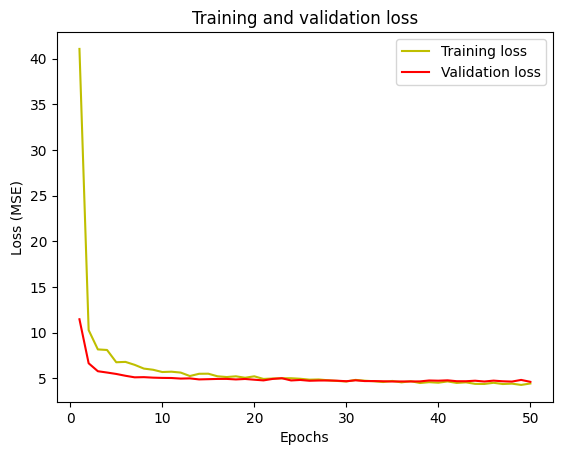

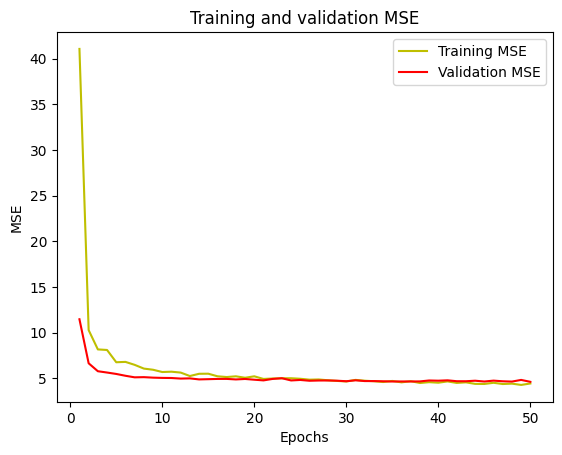

Test MSE: 4.4487
Test R-squared: 0.5904


In [3]:
#Regression

from tensorflow.keras import layers, models
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD,Adam
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score # Import regression metrics

X = df.drop('Rings', axis=1)
y = df['Rings'].values

scaler = StandardScaler()
X = scaler.fit_transform(X)


Y = y.reshape(-1, 1)

from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0)


model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",   # Mean Squared Error for regression
    metrics=["mse"] # Using mse as a metric for regression
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

y_pred = model.predict(X_test)

# For regression, y_test_class and y_pred_class using np.argmax are inappropriate.
# We are predicting continuous values, not classes. These lines are removed.

# 학습 곡선
loss = history.history['loss']
val_loss = history.history['val_loss']
# For regression, use 'mse' instead of 'accuracy'
mse = history.history['mse']
val_mse = history.history['val_mse']


# y_pred is already calculated above.

# Again, remove classification-specific conversions for regression
# y_test_class = np.argmax(y_test,axis=1)
# y_pred_class = np.argmax(y_pred,axis=1)

import matplotlib.pyplot as plt
import seaborn as sns

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)') # Update label
plt.legend()
plt.show()

# Plot MSE instead of Accuracy
plt.plot(epochs, mse, 'y', label='Training MSE')
plt.plot(epochs, val_mse, 'r', label='Validation MSE')
plt.title('Training and validation MSE') # Update title
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.show()

# Accuracy metrics (classification_report, confusion_matrix) are not applicable to regression.
# Replace with appropriate regression evaluation metrics.
# Calculate MSE and R-squared on the test set
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

print(f"Test MSE: {test_mse:.4f}")
print(f"Test R-squared: {test_r2:.4f}")

# Removed classification metrics
# from sklearn.metrics import classification_report,confusion_matrix
# print(classification_report(y_test_class,y_pred_class))
# print(confusion_matrix(y_test_class,y_pred_class))